<a href="https://colab.research.google.com/github/DakshL9/S4DS_Tasks/blob/main/S4DS_ML_Task1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [38]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import seaborn as sb

In [39]:
url="https://drive.google.com/file/d/1Efog2t2MWgm1Ciyn2nZyXqR9YAhUm7Ur/view?usp=sharing"
url='https://drive.google.com/uc?id=' + url.split('/')[-2] #stack overflow
df = pd.read_csv(url)


In [40]:
print(df.shape)  #rows and columns
df.dtypes      #datatypes

(120759, 23)


,0
ID,int64
Case Number,object
Date,object
Block,object
IUCR,object
Primary Type,object
Description,object
Location Description,object
Arrest,bool
Domestic,bool


In [41]:
df.describe()

,ID,Beat,District,Ward,Community Area,X Coordinate,Y Coordinate,Year,Latitude,Longitude,_year
count,1.207590e+05,120759.000000,120759.000000,120759.000000,120748.000000,1.188820e+05,1.188820e+05,120759.000000,118882.000000,118882.000000,120759.000000
mean,1.313421e+07,1151.098634,11.281039,23.322262,36.457730,1.165042e+06,1.887090e+06,2023.092432,41.845761,-87.669844,2023.092432
std,9.600914e+05,704.389546,7.038287,13.848473,21.456534,1.640964e+04,3.146721e+04,1.382963,0.086536,0.059751,1.382963
min,2.570300e+04,111.000000,1.000000,1.000000,1.000000,1.091242e+06,1.813914e+06,2021.000000,41.644604,-87.939733,2021.000000
25%,1.272905e+07,533.000000,5.000000,10.000000,23.000000,1.153358e+06,1.859960e+06,2022.000000,41.771113,-87.712334,2022.000000
50%,1.318890e+07,1033.000000,10.000000,24.000000,32.000000,1.167053e+06,1.894048e+06,2023.000000,41.865016,-87.662582,2023.000000
75%,1.363746e+07,1723.000000,17.000000,34.000000,53.000000,1.176659e+06,1.909520e+06,2024.000000,41.907369,-87.627271,2024.000000
max,1.428388e+07,2535.000000,31.000000,50.000000,77.000000,1.205114e+06,1.951499e+06,2025.000000,42.022537,-87.524616,2025.000000


In [42]:
df.head() #first 5

,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location,_year
0,13733090,JJ130321,01/28/2025 03:30:00 PM,076XX S RACINE AVE,0560,ASSAULT,SIMPLE,STREET,False,False,...,71.0,08A,1169643.0,1854247.0,2025,05/17/2025 03:40:52 PM,41.755554,-87.653868,"(41.755554244, -87.653867946)",2025
1,13909076,JJ344224,07/22/2025 12:40:00 PM,011XX W THORNDALE AVE,0560,ASSAULT,SIMPLE,TAVERN / LIQUOR STORE,True,False,...,77.0,08A,1167566.0,1939682.0,2025,03/14/2026 03:41:39 PM,41.990039,-87.659020,"(41.990039445, -87.659019968)",2025
2,13101860,JG295014,06/09/2023 08:23:00 PM,008XX S KOLMAR AVE,1507,PROSTITUTION,SOLICIT OFF PUBLIC WAY,STREET,True,False,...,26.0,16,1146144.0,1895827.0,2023,08/19/2023 03:40:26 PM,41.870133,-87.738933,"(41.870133029, -87.738933006)",2023
3,13701134,JH553823,12/24/2024 05:38:00 AM,043XX N KIMBALL AVE,0910,MOTOR VEHICLE THEFT,AUTOMOBILE,CONVENIENCE STORE,False,False,...,16.0,07,1152935.0,1928827.0,2024,11/02/2025 03:41:09 PM,41.960556,-87.713125,"(41.96055619, -87.71312483)",2024
4,13967696,JJ415709,09/15/2025 03:20:00 PM,004XX S WESTERN AVE,0312,ROBBERY,ARMED - KNIFE / CUTTING INSTRUMENT,CTA TRAIN,True,False,...,28.0,03,1160478.0,1897788.0,2025,03/14/2026 03:41:39 PM,41.875230,-87.686254,"(41.875229772, -87.686253982)",2025


In [43]:
df.tail() #last 5

,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location,_year
120754,12816225,JF383003,09/04/2022 12:00:00 AM,044XX S ALBANY AVE,1365,CRIMINAL TRESPASS,TO RESIDENCE,RESIDENCE,False,False,...,58.0,26,1156440.0,1875105.0,2022,01/03/2023 03:40:27 PM,41.813068,-87.701692,"(41.813067574, -87.701692471)",2022
120755,13643877,JH484130,10/26/2024 06:00:00 PM,030XX W 71ST ST,0560,ASSAULT,SIMPLE,APARTMENT,False,True,...,66.0,08A,1157400.0,1857393.0,2024,05/17/2025 03:40:52 PM,41.764444,-87.698651,"(41.764443935, -87.698650734)",2024
120756,13912639,JJ348512,07/25/2025 01:37:00 PM,065XX W DEVON AVE,1320,CRIMINAL DAMAGE,TO VEHICLE,STREET,False,False,...,10.0,14,1131902.0,1942088.0,2025,03/14/2026 03:41:39 PM,41.997337,-87.790145,"(41.997337332, -87.790144642)",2025
120757,13893174,JJ325121,07/07/2025 08:50:00 PM,020XX W 52ND ST,0460,BATTERY,SIMPLE,STREET,True,False,...,61.0,08B,1163588.0,1870007.0,2025,03/14/2026 03:41:39 PM,41.798931,-87.675616,"(41.798930883, -87.67561635)",2025
120758,12829854,JF399261,09/17/2022 03:28:00 AM,072XX S HALSTED ST,0430,BATTERY,AGGRAVATED - OTHER DANGEROUS WEAPON,STREET,True,False,...,68.0,04B,1172220.0,1856860.0,2022,01/03/2023 03:40:27 PM,41.762668,-87.644347,"(41.762668404, -87.644347199)",2022


In [44]:
print("Dataset information:")
print(f"Numerical columns: {len(df.select_dtypes(include=['number']).columns)}")
print(f"Text/Categorical columns: {len(df.select_dtypes(include=['object']).columns)}")

Dataset information:
Numerical columns: 11
Text/Categorical columns: 10


In [45]:
print(df['Year'].equals(df['_year']))
df = df.drop(columns="_year") #remove _year as same as Year

True


In [46]:
df.duplicated().sum()

np.int64(0)

In [47]:
print(df.shape)
dc=df.duplicated().sum()
if dc:
    df = df.drop_duplicates()
    print(f"Dropped {dc} duplicate rows. New shape: {df.shape}")

print(df.shape) #no duplicates found

(120759, 22)
(120759, 22)


In [48]:
df.isnull().sum()

,0
ID,0
Case Number,0
Date,0
Block,0
IUCR,0
Primary Type,0
Description,0
Location Description,463
Arrest,0
Domestic,0


Total missing values: 9859
Percentage missing: 0.37%


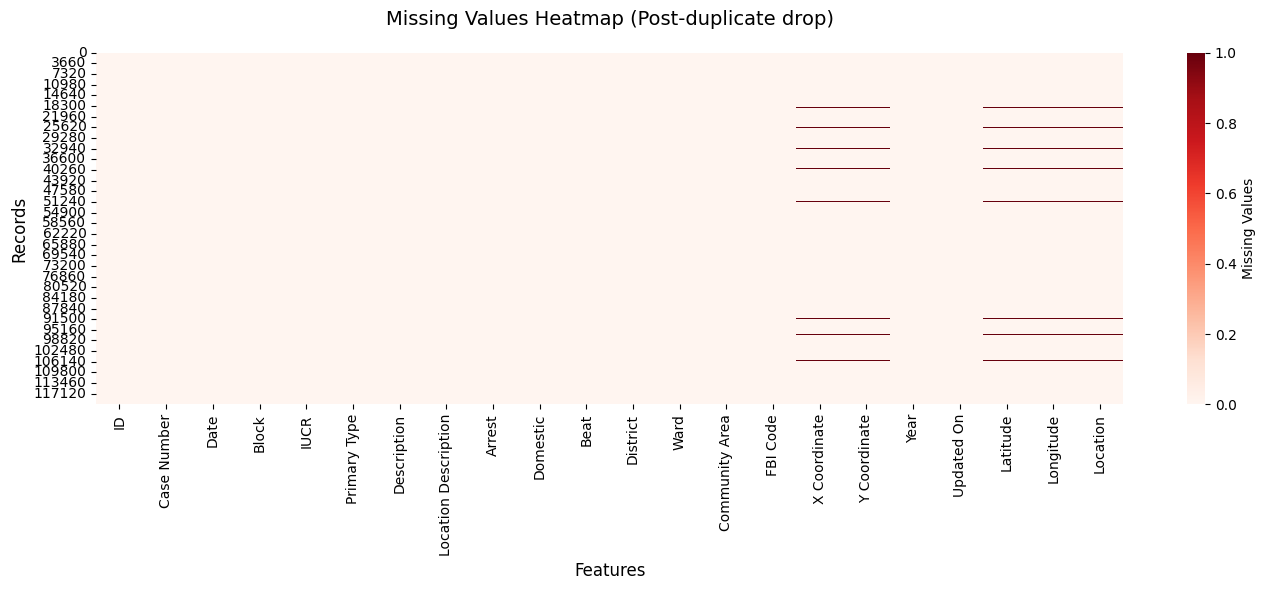

In [49]:
missing_stats = {
    'missing_values': df.isnull().sum(),
    'total_missing': df.isnull().sum().sum(),
    'total_cells': df.shape[0] * df.shape[1]
}

print(f"Total missing values: {missing_stats['total_missing']}")
print(f"Percentage missing: {(missing_stats['total_missing'] / missing_stats['total_cells']) * 100:.2f}%")

# clean, focused heatmap
fig, ax = mpl.pyplot.subplots(figsize=(14, 6))
sb.heatmap(df.isnull(), cbar=True, cmap='Reds',
           cbar_kws={'label': 'Missing Values'}, ax=ax)
ax.set_title('Missing Values Heatmap (Post-duplicate drop)', fontsize=14, pad=20)
ax.set_xlabel('Features', fontsize=12)
ax.set_ylabel('Records', fontsize=12)
mpl.pyplot.tight_layout()
mpl.pyplot.show()

#plot shows certain locations missing entirely (from each and every column related to it)


In [50]:
print("Percentage of Crimes correlating to missing locations: \n")
print((df[df['Latitude'].isnull()]['Primary Type'].value_counts(normalize=True).head(10))*100)

print("\n Percentageage of Crimes correlating to entire dataset: \n")
print((df['Primary Type'].value_counts(normalize=True).head(10))*100)

#change it to a pie-chart, doable

Percentage of Crimes correlating to missing locations: 

Primary Type
NARCOTICS                     30.687267
DECEPTIVE PRACTICE            23.974427
THEFT                         15.982952
BATTERY                        5.753863
OTHER OFFENSE                  5.380927
OFFENSE INVOLVING CHILDREN     3.409696
CRIMINAL DAMAGE                2.876931
ASSAULT                        2.184337
CRIMINAL SEXUAL ASSAULT        1.811401
SEX OFFENSE                    1.598295
Name: proportion, dtype: float64

 Percentageage of Crimes correlating to entire dataset: 

Primary Type
THEFT                  19.592743
BATTERY                18.498000
CRIMINAL DAMAGE         9.382323
ASSAULT                 8.563337
OTHER OFFENSE           6.791212
MOTOR VEHICLE THEFT     6.717512
WEAPONS VIOLATION       6.122939
DECEPTIVE PRACTICE      5.790045
NARCOTICS               5.708891
ROBBERY                 3.213011
Name: proportion, dtype: float64



===== Primary Type =====
Primary Type
THEFT              23660
BATTERY            22338
CRIMINAL DAMAGE    11330
ASSAULT            10341
OTHER OFFENSE       8201
Name: count, dtype: int64

===== Description =====
Description
SIMPLE                     13338
DOMESTIC BATTERY SIMPLE    10297
$500 AND UNDER              7169
OVER $500                   6923
RETAIL THEFT                6204
Name: count, dtype: int64

===== Location Description =====
Location Description
STREET                33558
APARTMENT             21907
RESIDENCE             13989
SIDEWALK               7798
SMALL RETAIL STORE     4070
Name: count, dtype: int64

===== Arrest =====
Arrest
False    81142
True     39617
Name: count, dtype: int64

===== Domestic =====
Domestic
False    97408
True     23351
Name: count, dtype: int64

===== District =====
District
11    8192
8     7509
6     7169
1     6910
12    6625
Name: count, dtype: int64

===== Ward =====
Ward
28.0    5970
27.0    5696
42.0    5210
24.0    4972
6.0 

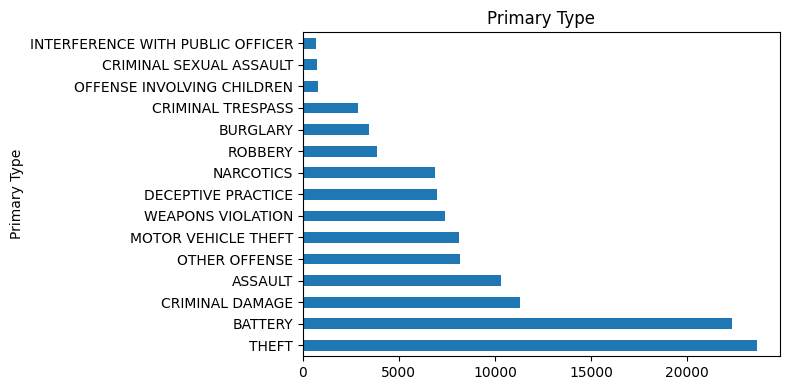

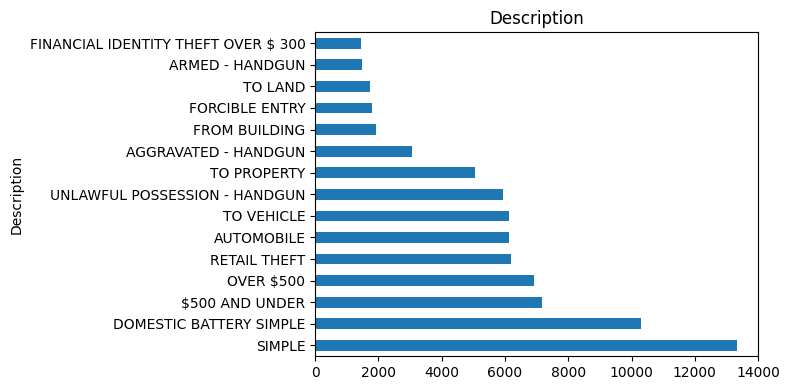

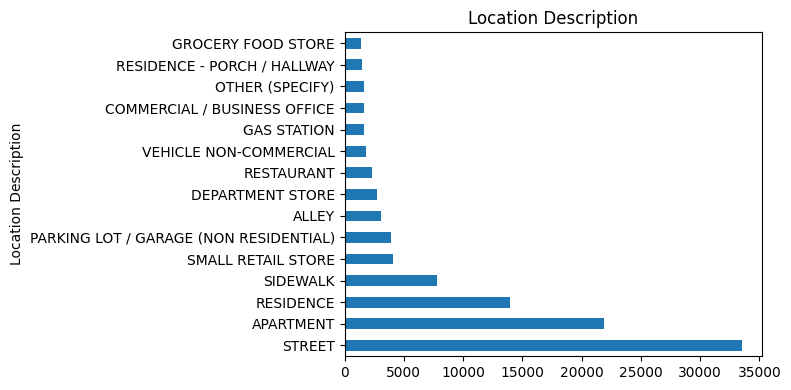

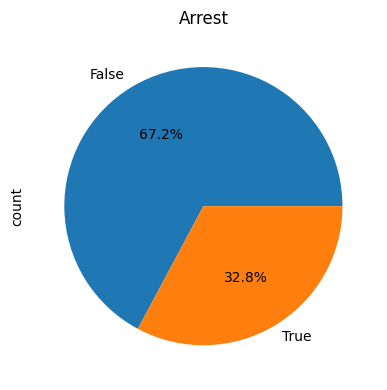

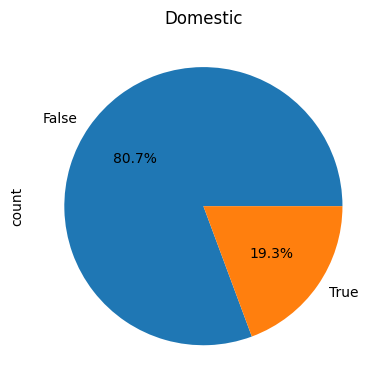

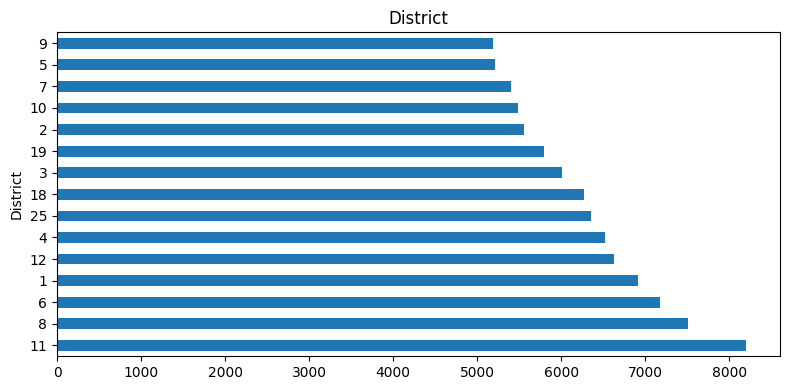

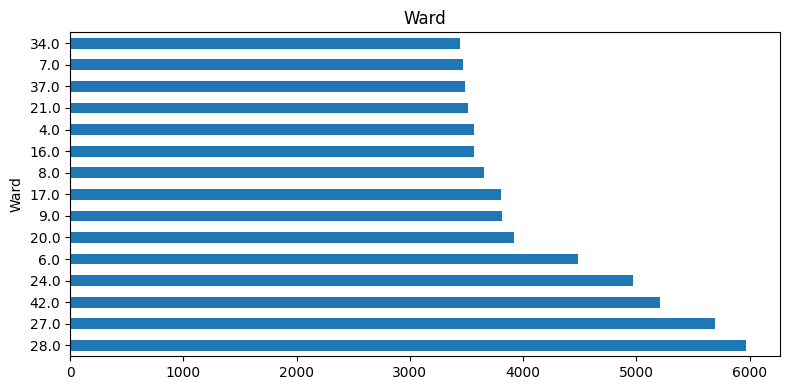

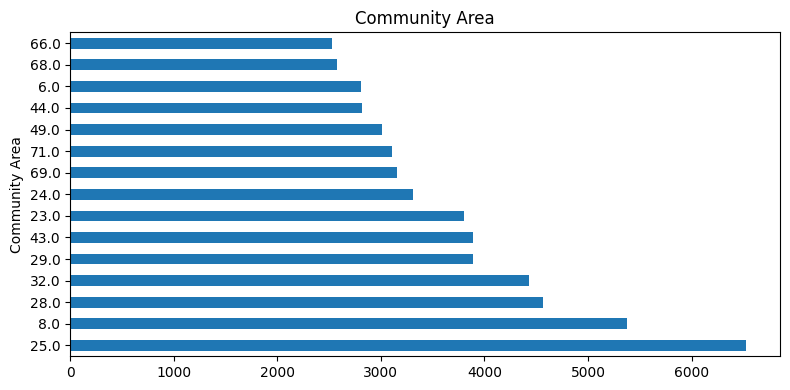

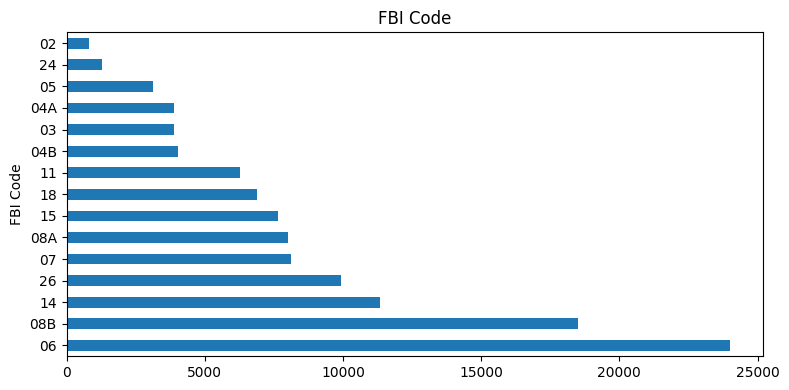

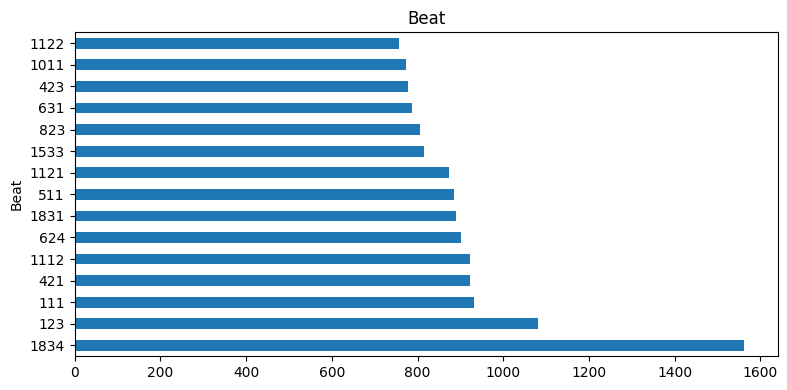

In [51]:
categorical_cols = ['Primary Type', 'Description', 'Location Description', 'Arrest',
                     'Domestic', 'District', 'Ward', 'Community Area', 'FBI Code', 'Beat']

numerical_cols = ['Latitude', 'Longitude', 'X Coordinate', 'Y Coordinate']

for col in categorical_cols:
    print(f"\n===== {col} =====")
    print(df[col].value_counts().head(5))

for col in categorical_cols:
    mpl.pyplot.figure(figsize=(8,4))

    if col in ['Arrest', 'Domestic']:
        df[col].value_counts().plot(kind='pie', autopct='%1.1f%%')
    else:
        df[col].value_counts().head(15).plot(kind='barh')

    mpl.pyplot.title(col)
    mpl.pyplot.tight_layout()
    mpl.pyplot.show()

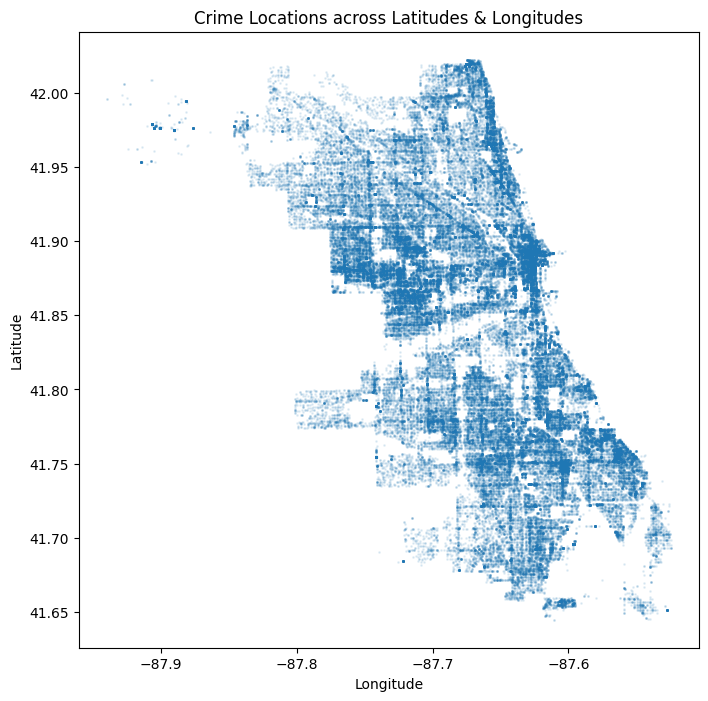

In [52]:
mpl.pyplot.figure(figsize=(8,8))
mpl.pyplot.scatter(df['Longitude'], df['Latitude'], alpha=0.1, s=1)
mpl.pyplot.title('Crime Locations across Latitudes & Longitudes')
mpl.pyplot.xlabel('Longitude')
mpl.pyplot.ylabel('Latitude')
mpl.pyplot.show()

In [53]:
df['Date_parsed'] = pd.to_datetime(df['Date'], format='%m/%d/%Y %I:%M:%S %p')

df['Hour'] = df['Date_parsed'].dt.hour
df['DayOfWeek'] = df['Date_parsed'].dt.day_name()
df['Month'] = df['Date_parsed'].dt.month_name()

exact_midnight_mask = (df['Date_parsed'].dt.time == pd.Timestamp('00:00:00').time())
n_dropped = exact_midnight_mask.sum()

df = df[~exact_midnight_mask].copy()

print(f"Dropped {n_dropped} rows with exact 00:00:00 timestamps")
print(f"New shape: {df.shape}")

Dropped 4072 rows with exact 00:00:00 timestamps
New shape: (116687, 26)


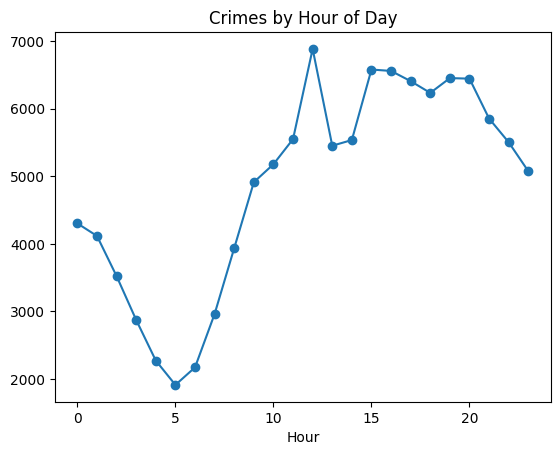

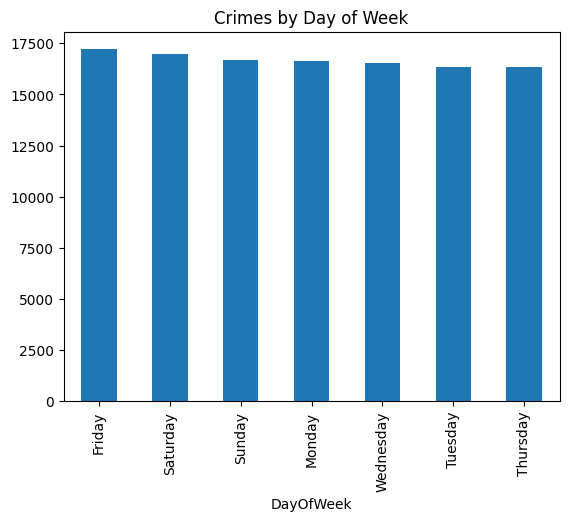

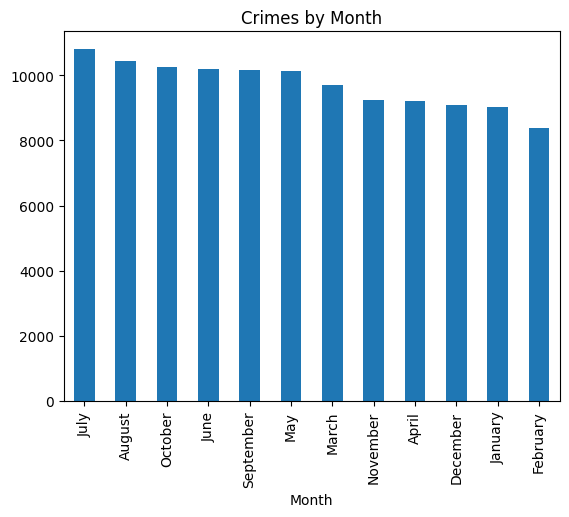

In [54]:
df['Hour'].value_counts().sort_index().plot(kind='line', marker='o')
mpl.pyplot.title('Crimes by Hour of Day')
mpl.pyplot.show()

df['DayOfWeek'].value_counts().plot(kind='bar')  # categorical, no natural numeric order needed but you can reindex
mpl.pyplot.title('Crimes by Day of Week')
mpl.pyplot.show()

df['Month'].value_counts().plot(kind='bar')
mpl.pyplot.title('Crimes by Month')
mpl.pyplot.show()

Top 5 crimes that end up with X percent of people arrested:
Primary Type
GAMBLING                             100.000000
CONCEALED CARRY LICENSE VIOLATION     99.218750
NARCOTICS                             98.930873
PROSTITUTION                          98.863636
LIQUOR LAW VIOLATION                  97.826087
Name: Arrest, dtype: float64

Bottom 5 crimes that end up with X percent of people arrested:
Primary Type
MOTOR VEHICLE THEFT    9.052388
DECEPTIVE PRACTICE     8.986928
KIDNAPPING             7.142857
INTIMIDATION           2.985075
HUMAN TRAFFICKING      0.000000
Name: Arrest, dtype: float64


<Axes: ylabel='Primary Type'>

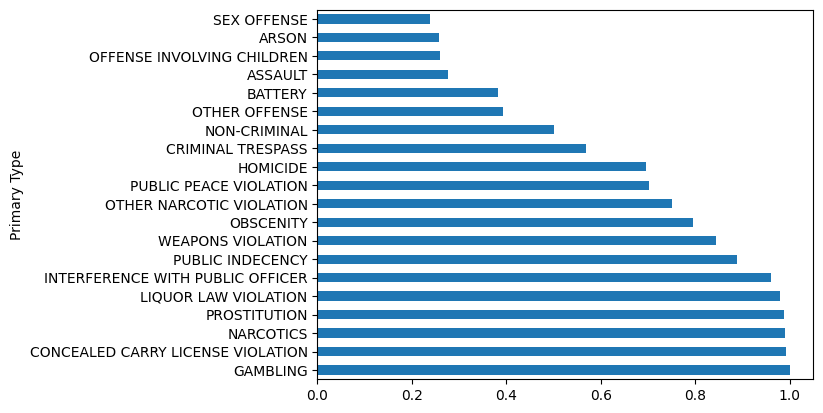

In [55]:
print("Top 5 crimes that end up with X percent of people arrested:")
print((df.groupby('Primary Type')['Arrest'].mean()*100).sort_values(ascending=False).head(5))
print()
print("Bottom 5 crimes that end up with X percent of people arrested:")
print((df.groupby('Primary Type')['Arrest'].mean()*100).sort_values(ascending=False).tail(5))

df.groupby('Primary Type')['Arrest'].mean().sort_values(ascending=False).head(20).plot(kind='barh')

<Axes: xlabel='Primary Type', ylabel='District'>

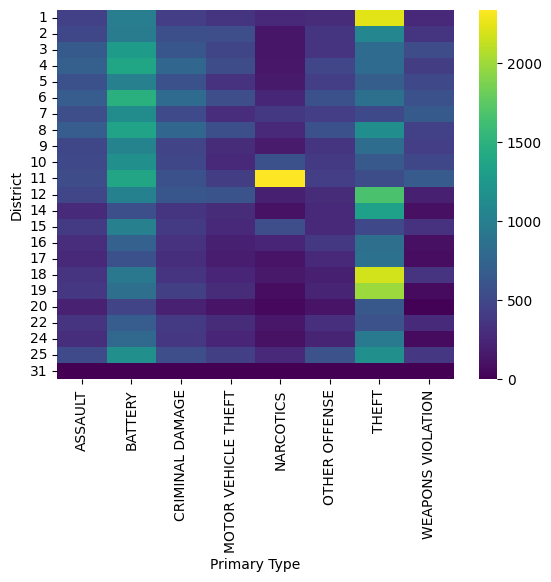

In [56]:
sb.heatmap(pd.crosstab(df['District'], subset['Primary Type']), cmap='viridis')

<Axes: >

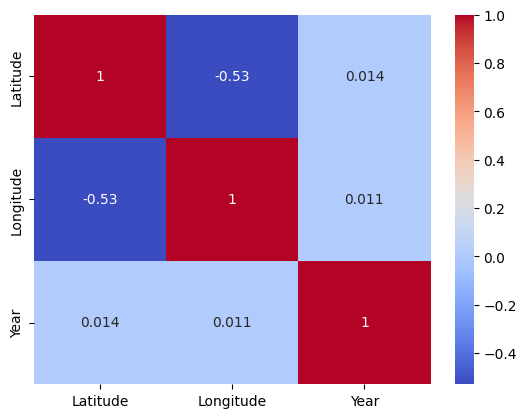

In [57]:
df[['Latitude','Longitude','Year']].corr()
sb.heatmap(df[['Latitude','Longitude','Year']].corr(), annot=True,cmap='coolwarm')

<Axes: >

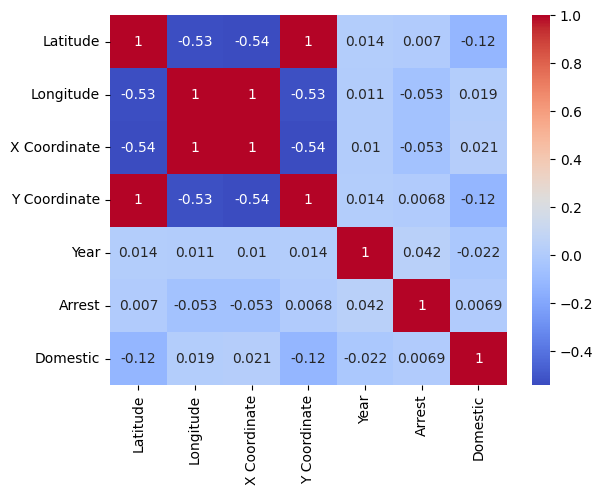

In [58]:
numeric_subset = ['Latitude','Longitude','X Coordinate','Y Coordinate','Year','Arrest','Domestic']
sb.heatmap(df[numeric_subset].corr(), annot=True, cmap='coolwarm')

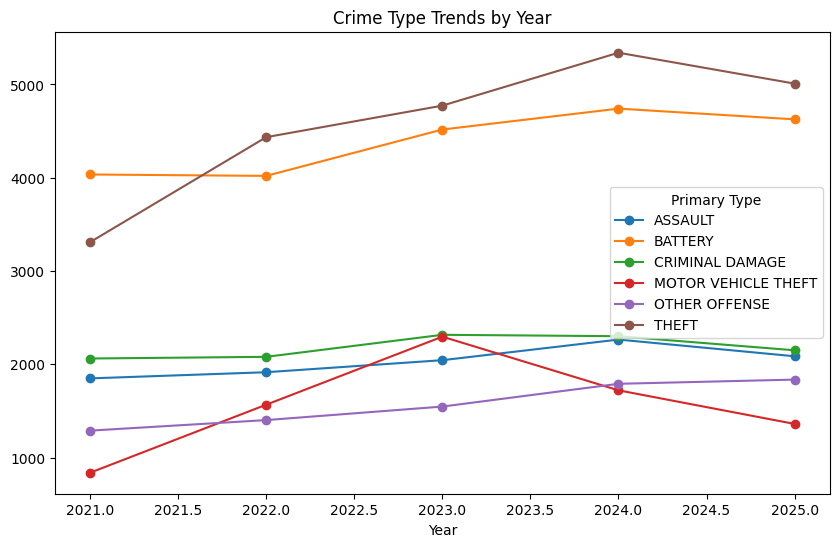

In [59]:
top_crimes = df['Primary Type'].value_counts().head(6).index
subset = df[df['Primary Type'].isin(top_crimes)]

trend = pd.crosstab(subset['Year'], subset['Primary Type'])
trend.plot(kind='line', marker='o', figsize=(10,6))
mpl.pyplot.title('Crime Type Trends by Year')
mpl.pyplot.show()

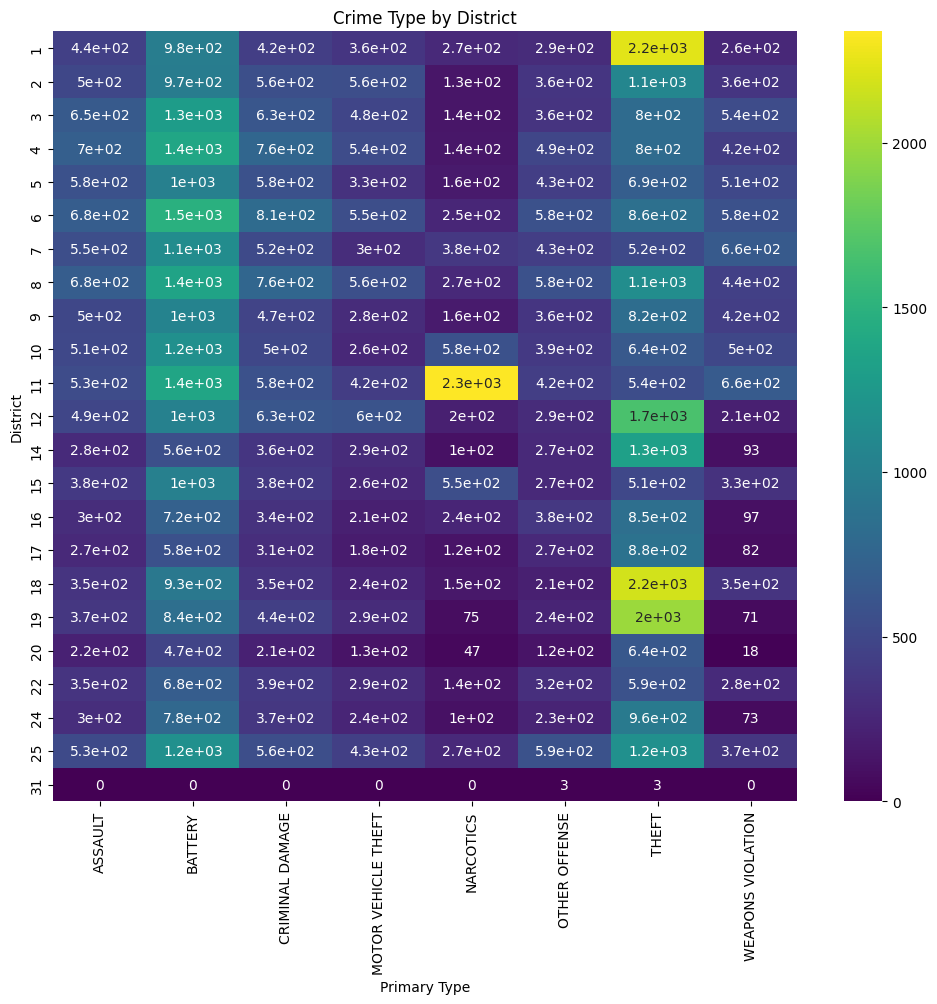

In [60]:
top_crimes = df['Primary Type'].value_counts().head(8).index
subset = df[df['Primary Type'].isin(top_crimes)]

heatmap_data = pd.crosstab(subset['District'], subset['Primary Type'])

mpl.pyplot.figure(figsize=(12, 10))
sb.heatmap(heatmap_data, cmap='viridis', annot=True)
mpl.pyplot.title('Crime Type by District')
mpl.pyplot.xlabel('Primary Type')
mpl.pyplot.ylabel('District')
mpl.pyplot.show()